In [1]:
from google.colab import files

files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
!kaggle datasets download zalando-research/fashionmnist
!unzip fashionmnist.zip

Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
  0% 0.00/68.8M [00:00<?, ?B/s]
100% 68.8M/68.8M [00:00<00:00, 1.39GB/s]
Archive:  fashionmnist.zip
  inflating: fashion-mnist_test.csv  
  inflating: fashion-mnist_train.csv  
  inflating: t10k-images-idx3-ubyte  
  inflating: t10k-labels-idx1-ubyte  
  inflating: train-images-idx3-ubyte  
  inflating: train-labels-idx1-ubyte  


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset , DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [4]:
torch.manual_seed(42)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [6]:
 df = pd.read_csv('/content/fashion-mnist_train.csv')

In [7]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df.shape

(60000, 785)

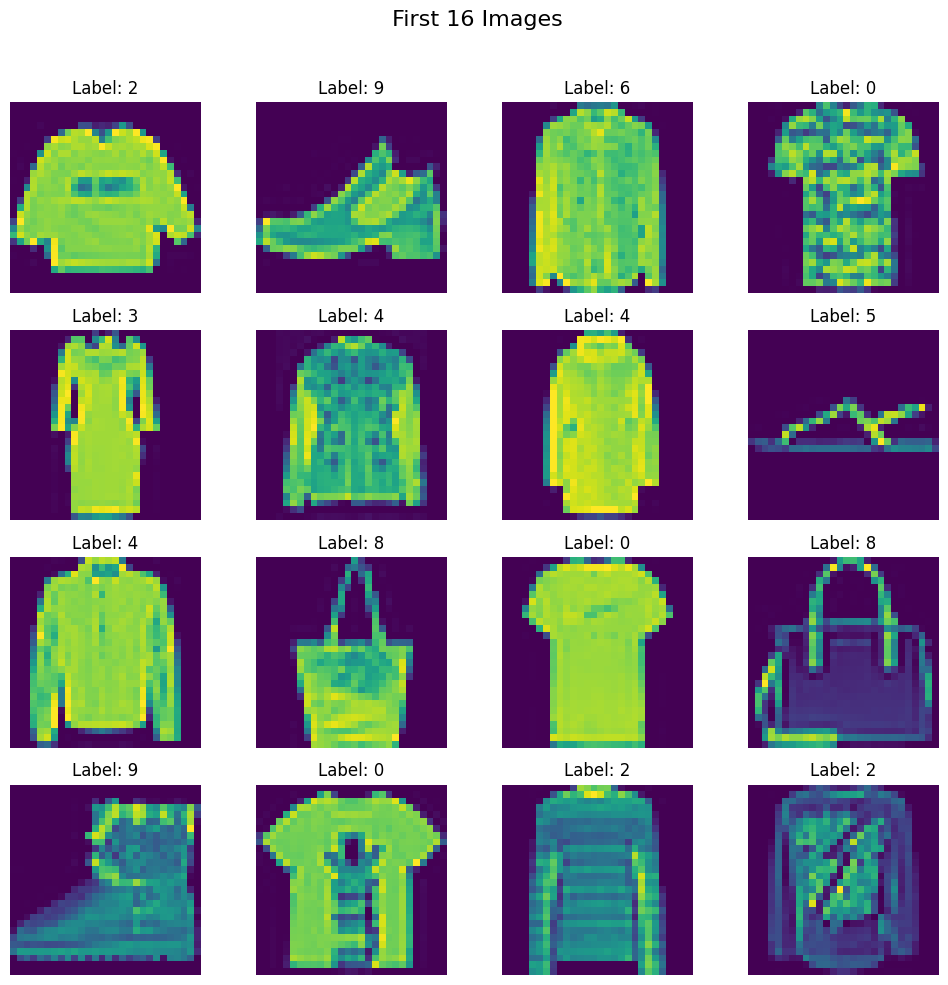

In [9]:
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle(" First 16 Images" , fontsize=16)

for i,ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i,0]}")


plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


In [10]:
x = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [11]:
x_train , x_test, y_train , y_test = train_test_split(x,y , test_size=0.2 , random_state=42)

In [12]:
x_train= x_train/255.0
x_test= x_test/255.0

In [13]:
x_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.        ,
        0.        ]])

In [14]:
class CustomDataset(Dataset):

    def __init__(self, features , labels):

        self.features = torch.tensor(features , dtype=torch.float32)
        self.labels = torch.tensor(labels , dtype=torch.long)

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, index):
        return self.features[index] , self.labels[index]

In [15]:
train_dataset = CustomDataset(x_train, y_train)
test_dataset = CustomDataset(x_test , y_test)

In [16]:
len(train_dataset)

48000

In [18]:
len(train_loader)

47

In [29]:
class MyNN(nn.Module):

    def __init__(self , input_dim , output_dim , num_hidden_layers , neurons_per_layer , dropout_rate):

        super().__init__()

        layers = []

        for i in range(num_hidden_layers):
          layers.append(nn.Linear(input_dim , neurons_per_layer))
          layers.append(nn.BatchNorm1d(neurons_per_layer))
          layers.append(nn.ReLU())
          layers.append(nn.Dropout(p=dropout_rate))
          input_dim = neurons_per_layer

        layers.append(nn.Linear(neurons_per_layer , output_dim))

        self.model= nn.Sequential(
            *layers
        )


    def forward(self, x):

        return self.model(x)

In [30]:
#objective function
def objective(trial):

  #next hyperparameter values from the search space
  num_hidden_layers = trial.suggest_int('num_hidden_layers', 1, 5)
  neurons_per_layer = trial.suggest_int('neurons_per_layer', 8, 128, step=8)
  epochs = trial.suggest_int('epochs', 10, 150, step=10)
  learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
  dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
  batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256, 512])
  optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'SGD', 'RMSprop'])
  weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-1, log=True)

  #data loader

  train_loader = DataLoader(train_dataset , batch_size=batch_size , shuffle=True , pin_memory=True)
  test_loader = DataLoader(test_dataset , batch_size=batch_size , shuffle=False , pin_memory=True)

  #model init
  input_dim = 784
  output_dim = 10

  model = MyNN(input_dim , output_dim , num_hidden_layers , neurons_per_layer, dropout_rate)
  model = model.to(device)

  #params init


  #optimizer selection
  criterion = nn.CrossEntropyLoss()

  if optimizer_name == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr=learning_rate , weight_decay=weight_decay)
  elif optimizer_name == 'RMSprop':
    optimizer = optim.RMSprop(model.parameters(), lr=learning_rate , weight_decay=weight_decay)
  else:
    optimizer = optim.SGD(model.parameters(), lr=learning_rate , weight_decay=weight_decay)

  #training loop

  for epoch in range(epochs):
      total_epoch_loss =0
      for batch_features , batch_labels in train_loader:
          # move data to gpu
          batch_features = batch_features.to(device)
          batch_labels = batch_labels.to(device)

          #forward pass
          y_pred = model(batch_features)

          #loss calculate
          loss = criterion(y_pred, batch_labels)

          #zero grad for next epoch not needed accumulate for grad
          # It is better to make it zero before calculation than after
          optimizer.zero_grad()
          #backward pass
          loss.backward()
          #parameter update
          optimizer.step()
          total_epoch_loss = total_epoch_loss+ loss.item()

      print(f"Epoch: {epoch+1} -> Loss: {total_epoch_loss/len(train_loader)}")

  #evaluation
  model.eval()
  total=0
  correct=0

  with torch.no_grad():
      for batch_features, batch_labels in test_loader:

          # move data to gpu
          batch_features = batch_features.to(device)
          batch_labels = batch_labels.to(device)


          outputs = model(batch_features)##give 1024,10

          _, predicted = torch.max(outputs,1)

          total = total + batch_labels.shape[0]
          correct = correct + (predicted==batch_labels).sum().item()

  print(correct/total)


  return correct/total

In [24]:
!pip install optuna

In [32]:
import optuna

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2025-09-11 14:38:48,961] A new study created in memory with name: no-name-59bba453-cf67-4352-81f7-3122d31283e4


Epoch: 1 -> Loss: 2.238691228866577
Epoch: 2 -> Loss: 2.0306636012395223
Epoch: 3 -> Loss: 1.8642376623153687
Epoch: 4 -> Loss: 1.7230598694483439
Epoch: 5 -> Loss: 1.6041612180074056
Epoch: 6 -> Loss: 1.5031624666849772
Epoch: 7 -> Loss: 1.4125886939366659
Epoch: 8 -> Loss: 1.3388978748321534
Epoch: 9 -> Loss: 1.271950533548991
Epoch: 10 -> Loss: 1.2133197552363078
Epoch: 11 -> Loss: 1.1594931939442952
Epoch: 12 -> Loss: 1.1144178382555643
Epoch: 13 -> Loss: 1.075735946337382
Epoch: 14 -> Loss: 1.0427892495791118
Epoch: 15 -> Loss: 1.0090988357861836
Epoch: 16 -> Loss: 0.9859135033289591
Epoch: 17 -> Loss: 0.9571136277516683
Epoch: 18 -> Loss: 0.9316745483080546
Epoch: 19 -> Loss: 0.9150564220746358
Epoch: 20 -> Loss: 0.8956427768071492
Epoch: 21 -> Loss: 0.8775374525388082
Epoch: 22 -> Loss: 0.8662731773058573
Epoch: 23 -> Loss: 0.8555255668958028
Epoch: 24 -> Loss: 0.838363659063975
Epoch: 25 -> Loss: 0.8292241929372152
Epoch: 26 -> Loss: 0.8143875363667806
Epoch: 27 -> Loss: 0.8017

[I 2025-09-11 14:41:19,054] Trial 0 finished with value: 0.8598333333333333 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 64, 'epochs': 110, 'learning_rate': 0.0010062988705525691, 'dropout_rate': 0.30000000000000004, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.00023389940000415613}. Best is trial 0 with value: 0.8598333333333333.


Epoch: 110 -> Loss: 0.5444129360516866
0.8598333333333333
Epoch: 1 -> Loss: 2.0092388820648193
Epoch: 2 -> Loss: 1.6171886835098266
Epoch: 3 -> Loss: 1.3851790987650554
Epoch: 4 -> Loss: 1.2252397342522938
Epoch: 5 -> Loss: 1.1149386233488718
Epoch: 6 -> Loss: 1.0329132941563923
Epoch: 7 -> Loss: 0.9697877639134725
Epoch: 8 -> Loss: 0.9188545000553131
Epoch: 9 -> Loss: 0.8806263524691264
Epoch: 10 -> Loss: 0.8478316703637441
Epoch: 11 -> Loss: 0.8145458441575368
Epoch: 12 -> Loss: 0.7987474061648051
Epoch: 13 -> Loss: 0.774828646183014
Epoch: 14 -> Loss: 0.7561534025271733
Epoch: 15 -> Loss: 0.7357061452865601
Epoch: 16 -> Loss: 0.7285163725217183
Epoch: 17 -> Loss: 0.7085158015092214
Epoch: 18 -> Loss: 0.6981136568387349
Epoch: 19 -> Loss: 0.6910855417648951
Epoch: 20 -> Loss: 0.6818171739578247
Epoch: 21 -> Loss: 0.6708814663092295
Epoch: 22 -> Loss: 0.6636351696252822
Epoch: 23 -> Loss: 0.6565892012914022
Epoch: 24 -> Loss: 0.6490666366815567
Epoch: 25 -> Loss: 0.6396461007992427
Ep

[I 2025-09-11 14:45:49,562] Trial 1 finished with value: 0.8853333333333333 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 80, 'epochs': 130, 'learning_rate': 0.0007411960536624232, 'dropout_rate': 0.30000000000000004, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.014450303640236008}. Best is trial 1 with value: 0.8853333333333333.


...

Epoch: 130 -> Loss: 0.4005328811009725
0.87575
Epoch: 1 -> Loss: 0.9154722373536293
Epoch: 2 -> Loss: 0.5373426073409141
Epoch: 3 -> Loss: 0.48528687021833783
Epoch: 4 -> Loss: 0.4530189814085656
Epoch: 5 -> Loss: 0.43204897356794236
Epoch: 6 -> Loss: 0.4164132019306751
Epoch: 7 -> Loss: 0.39987746229831206
Epoch: 8 -> Loss: 0.39070726582344545
Epoch: 9 -> Loss: 0.3815774552999659


[I 2025-09-11 15:20:36,947] Trial 18 finished with value: 0.8746666666666667 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 120, 'epochs': 10, 'learning_rate': 0.0013340386007137301, 'dropout_rate': 0.4, 'batch_size': 512, 'optimizer': 'Adam', 'weight_decay': 0.00012237197261612785}. Best is trial 12 with value: 0.8908333333333334.


Epoch: 10 -> Loss: 0.37160310688170983
0.8746666666666667
Epoch: 1 -> Loss: 1.0437693464756013
Epoch: 2 -> Loss: 1.0984174823760986
Epoch: 3 -> Loss: 1.1271695080598196
Epoch: 4 -> Loss: 1.158391529560089
Epoch: 5 -> Loss: 1.1413172156016032
Epoch: 6 -> Loss: 1.1546550557613373
Epoch: 7 -> Loss: 1.1887575608094534
Epoch: 8 -> Loss: 1.182796173731486
Epoch: 9 -> Loss: 1.2092041988372804
Epoch: 10 -> Loss: 1.1951436315377553
Epoch: 11 -> Loss: 1.2117185044288634
Epoch: 12 -> Loss: 1.2326711422602337
Epoch: 13 -> Loss: 1.2149437075455984
Epoch: 14 -> Loss: 1.2456212974389393
Epoch: 15 -> Loss: 1.2197455951372782
Epoch: 16 -> Loss: 1.2434593597253163
Epoch: 17 -> Loss: 1.2294339168866475
Epoch: 18 -> Loss: 1.2207307175000508
Epoch: 19 -> Loss: 1.2497688846588135
Epoch: 20 -> Loss: 1.2447831269105276
Epoch: 21 -> Loss: 1.2580252230167388
Epoch: 22 -> Loss: 1.2753264440695444
Epoch: 23 -> Loss: 1.2877591825326284
Epoch: 24 -> Loss: 1.2745655776659648
Epoch: 25 -> Loss: 1.2787029082775117
Epo

[I 2025-09-11 15:24:40,689] Trial 19 finished with value: 0.61225 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 96, 'epochs': 120, 'learning_rate': 0.08691345355335411, 'dropout_rate': 0.30000000000000004, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0005859668050465886}. Best is trial 12 with value: 0.8908333333333334.


Epoch: 120 -> Loss: 1.2566177486578622
0.61225


In [26]:
study.best_value

0.8838333333333334

In [27]:
study.best_params

{'num_hidden_layers': 1, 'neurons_per_layer': 128}